# Урок 1. Пайплайны, честная валидация и метрики

🎯 **Цели урока**

- собрать предобработку и модель в один `Pipeline`, чтобы исключить утечки;
- оценить модель кросс-валидацией и понять, насколько оценке можно верить;
- своими руками устроить три утечки и увидеть, как они «улучшают» качество;
- разобраться в метриках классификации, выбрать порог под задачу, проверить калибровку.

📖 **Теория:** разделы «Валидация» и «Метрики».

**Данные:** Adult (перепись США 1994 года, лицензия CC BY 4.0): по анкете человека предсказать,
зарабатывает ли он больше $50 тысяч в год. Скачивается при первом запуске (0,6 МБ).

In [1]:
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from mlcourse import fetch

pd.set_option("display.width", 120)
rng = np.random.default_rng(0)

## 1. Данные

In [2]:
COLUMNS = [
    "age", "workclass", "fnlwgt", "education", "education_num", "marital_status", "occupation",
    "relationship", "race", "sex", "capital_gain", "capital_loss", "hours_per_week", "native_country", "income",
]

with zipfile.ZipFile(fetch("adult") / "adult.zip") as z:
    parts = [
        pd.read_csv(z.open(name), names=COLUMNS, skipinitialspace=True, na_values="?", skiprows=skip)
        for name, skip in [("adult.data", 0), ("adult.test", 1)]
    ]
df = pd.concat(parts, ignore_index=True)
df["income"] = df["income"].str.rstrip(".")  # в тестовом файле метки с точкой: ">50K."

y = (df["income"] == ">50K").astype(int)
X = df.drop(columns=["income", "fnlwgt"])  # fnlwgt — вес строки в выборке переписи, не признак человека
print(X.shape)
X.head()

(48842, 13)


,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [3]:
print("доля >50K:", round(y.mean(), 3))
print("пропуски:", X.isna().sum()[lambda s: s > 0].to_dict())

доля >50K: 0.239
пропуски: {'workclass': 2799, 'occupation': 2809, 'native_country': 857}


Положительных 24%. Значит, модель «всегда ≤50K» имеет accuracy 76%. Это наш baseline:
всё, что ниже, хуже константы.

Сразу откладываем тестовую выборку и не трогаем её до конца урока.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
print(len(X_train), len(X_test))

39073 9769


## 2. Пайплайн

Числовые признаки: заполнить пропуски медианой, стандартизовать. Категориальные: заполнить
самым частым значением и закодировать one-hot; редкие категории (меньше 20 объектов) объединить.
`ColumnTransformer` применяет разную обработку к разным столбцам, а `Pipeline` склеивает её
с моделью. Всё, что «учится» (медианы, средние, список категорий), учится только на train.

In [5]:
numeric = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
categorical = [c for c in X.columns if c not in numeric]

preprocess = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numeric),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=20)), categorical),
])
model = make_pipeline(preprocess, LogisticRegression(max_iter=2000))
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float,

## 3. Кросс-валидация

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_validate(model, X_train, y_train, cv=cv,
                        scoring=["accuracy", "f1", "roc_auc", "average_precision"])
summary = pd.DataFrame({k.removeprefix("test_"): v for k, v in scores.items() if k.startswith("test_")})
summary.agg(["mean", "std"]).round(3)

,accuracy,f1,roc_auc,average_precision
mean,0.850,0.653,0.904,0.762
std,0.004,0.009,0.002,0.010


Accuracy 0,85 при baseline 0,76. ROC-AUC 0,90. Разброс по фолдам — сотые доли: на 39 тысячах
объектов оценка стабильна. Если бы стандартное отклонение было сравнимо с разницей между моделями,
сравнивать их по одному разбиению было бы бессмысленно.

## 4. Утечки своими руками

### Утечка 1: отбор признаков до кросс-валидации

Возьмём **чистый шум**: 200 объектов, 10 000 случайных признаков, случайные метки.
Никакая модель не может предсказать такие метки лучше 50%.

In [7]:
X_noise = rng.normal(size=(200, 10_000))
y_noise = rng.integers(0, 2, size=200)

# ❌ неправильно: выбрали 20 «лучших» признаков по всем данным, потом кросс-валидация
selected = SelectKBest(f_classif, k=20).fit_transform(X_noise, y_noise)
wrong = cross_val_score(LogisticRegression(), selected, y_noise, cv=cv).mean()

# ✅ правильно: отбор признаков внутри пайплайна — на каждом фолде заново, только по train
right = cross_val_score(make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression()),
                        X_noise, y_noise, cv=cv).mean()
print(f"отбор до CV: {wrong:.2f}    отбор внутри CV: {right:.2f}")

отбор до CV: 0.86    отбор внутри CV: 0.53


На шуме «получилась» точность заметно выше 50%: признаки выбраны так, чтобы случайно коррелировать
с метками *всех* объектов, включая те, что потом попадут в валидацию. Эта ошибка встречалась
даже в опубликованных научных статьях.

### Утечка 2: признак из будущего

Добавим признак «налоговая категория», которую в реальности присваивают *по доходу*. В момент
прогноза её не может быть, но в выгрузке из базы она легко окажется рядом с другими столбцами.

In [8]:
X_leak = X_train.copy()
noise = rng.random(len(y_train)) < 0.05  # 5% записей с ошибкой — чтобы было «правдоподобно»
X_leak["tax_bracket"] = np.where(y_train.to_numpy() ^ noise, "high", "normal")

leaky = make_pipeline(
    ColumnTransformer([("num", StandardScaler(), numeric),
                       ("cat", OneHotEncoder(handle_unknown="ignore"), categorical + ["tax_bracket"])]),
    LogisticRegression(max_iter=2000),
)
print("ROC-AUC с «налоговой категорией»:", cross_val_score(leaky, X_leak.fillna("нет"), y_train, cv=cv,
                                                          scoring="roc_auc").mean().round(3))

ROC-AUC с «налоговой категорией»: 0.99


ROC-AUC 0,99 на задаче, где честная модель даёт 0,90. **Слишком хорошо, чтобы быть правдой** —
первый сигнал утечки. Проверка: для каждого признака спросить «известен ли он в момент прогноза?»
и посмотреть на самые важные признаки модели.

### Утечка 3: дубликаты между train и test

Если одни и те же объекты попали и в обучение, и в проверку, модель, которая умеет *запоминать*,
получает незаслуженную оценку. Добавим в данные копии 30% строк и сравним случайный лес
на честном и «загрязнённом» тесте.

In [9]:
forest = make_pipeline(
    ColumnTransformer([("num", "passthrough", numeric),
                       ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20), categorical)]),
    RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=0),
)
X_small, y_small = X_train.fillna("нет").iloc[:10_000], y_train.iloc[:10_000]
dup = X_small.sample(frac=0.3, random_state=0).index
X_dup = pd.concat([X_small, X_small.loc[dup]])
y_dup = pd.concat([y_small, y_small.loc[dup]])

for name, (xs, ys) in {"без дубликатов": (X_small, y_small), "с дубликатами": (X_dup, y_dup)}.items():
    xa, xb, ya, yb = train_test_split(xs, ys, test_size=0.3, random_state=1)
    auc = roc_auc_score(yb, forest.fit(xa, ya).predict_proba(xb)[:, 1])
    print(f"{name:15} ROC-AUC = {auc:.3f}")

без дубликатов  ROC-AUC = 0.886


с дубликатами   ROC-AUC = 0.930


Плюс четыре сотых ROC-AUC без единого изменения в модели: случайный лес просто узнаёт объекты,
которые видел при обучении. Эффект растёт с долей дубликатов и «памятью» модели.
В NLP и RAG дубликаты и почти-дубликаты встречаются постоянно: одинаковые шаблонные ответы,
перепечатки новостей, версии одного документа. Дедупликация — до разбиения.

## 5. Метрики на тестовой выборке

Обучаем финальную модель на всём train и **один раз** смотрим на test.

In [10]:
model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, target_names=["≤50K", ">50K"], digits=3))

[[6931  500]
 [ 923 1415]]
              precision    recall  f1-score   support

        ≤50K      0.882     0.933     0.907      7431
        >50K      0.739     0.605     0.665      2338

    accuracy                          0.854      9769
   macro avg      0.811     0.769     0.786      9769
weighted avg      0.848     0.854     0.849      9769



Строки матрицы ошибок — истинные классы, столбцы — предсказанные. Для класса >50K precision
заметно выше recall: при пороге 0,5 модель осторожна и находит лишь часть людей с высоким доходом.

### ROC и PR

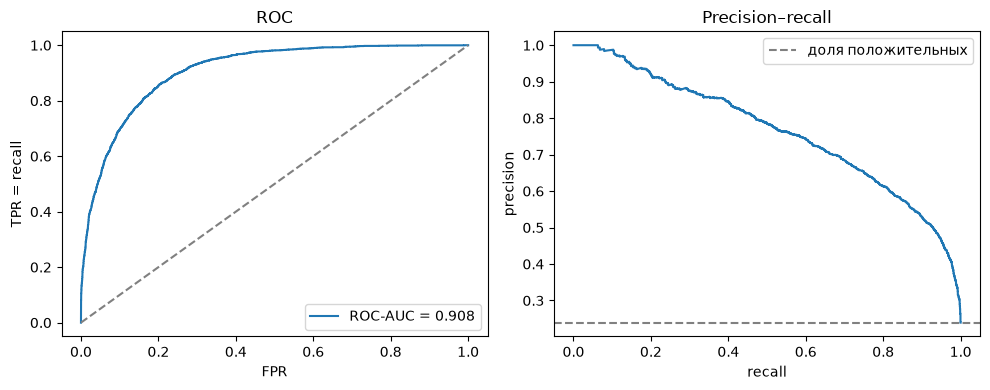

In [11]:
fpr, tpr, _ = roc_curve(y_test, proba)
prec, rec, thr = precision_recall_curve(y_test, proba)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
a1.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, proba):.3f}")
a1.plot([0, 1], [0, 1], "--", color="gray")
a1.set(xlabel="FPR", ylabel="TPR = recall", title="ROC")
a1.legend()
a2.plot(rec, prec)
a2.axhline(y_test.mean(), ls="--", color="gray", label="доля положительных")
a2.set(xlabel="recall", ylabel="precision", title="Precision–recall")
a2.legend()
plt.tight_layout()
plt.show()

### Выбор порога

Допустим, по бизнес-требованию нужно находить не меньше 80% людей с высоким доходом (recall ≥ 0,8).
Порог выбираем **на train** по предсказаниям кросс-валидации, а на test только проверяем.

In [12]:
oof = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
p_tr, r_tr, t_tr = precision_recall_curve(y_train, oof)
ok = r_tr[:-1] >= 0.8                    # у последней точки кривой нет порога
threshold = t_tr[ok][-1]                 # самый высокий порог, при котором recall ещё ≥ 0,8
print(f"порог: {threshold:.3f}")

pred_t = (proba >= threshold).astype(int)
tp = ((pred_t == 1) & (y_test == 1)).sum()
print(f"test: recall = {tp / y_test.sum():.3f}, precision = {tp / pred_t.sum():.3f}")

порог: 0.285
test: recall = 0.824, precision = 0.595


Recall на тесте близок к целевому, а precision упал — за полноту платим ложными тревогами.
Порог — такой же параметр модели, как её веса, и выбирать его на тесте нельзя.

## 6. Калибровка

Сравним логистическую регрессию со случайным лесом: откалиброваны ли их вероятности?

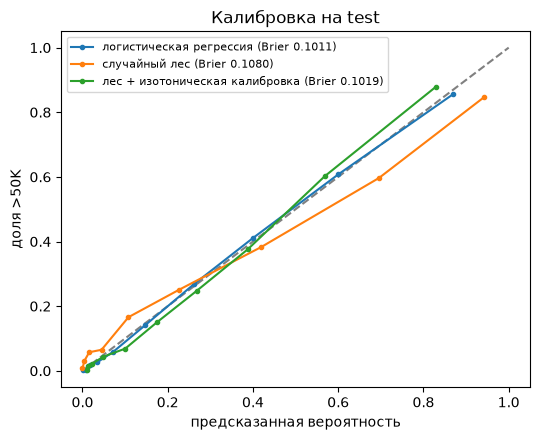

In [13]:
X_cal = X_train.fillna("нет")
forest_cal = CalibratedClassifierCV(forest, method="isotonic", cv=3)
models = {
    "логистическая регрессия": model,
    "случайный лес": forest.fit(X_cal, y_train),
    "лес + изотоническая калибровка": forest_cal.fit(X_cal, y_train),
}

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot([0, 1], [0, 1], "--", color="gray")
for name, m in models.items():
    p = m.predict_proba(X_test.fillna("нет") if m is not model else X_test)[:, 1]
    frac, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac, marker="o", ms=3, label=f"{name} (Brier {brier_score_loss(y_test, p):.4f})")
ax.set(xlabel="предсказанная вероятность", ylabel="доля >50K", title="Калибровка на test")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Чем ближе кривая к диагонали и чем меньше Brier score, тем лучше вероятностям можно верить
«как числам». Изотоническая калибровка на отложенных фолдах подтягивает кривую леса к диагонали.

## 7. Метрики по группам

Средняя метрика может скрывать, что модель работает хуже для части людей. Посчитаем recall
(долю найденных людей с высоким доходом) отдельно по полу.

In [14]:
report = pd.DataFrame({"sex": X_test["sex"], "y": y_test, "pred": pred})
by_group = report.groupby("sex").apply(
    lambda g: pd.Series({"доля >50K": g.y.mean(), "recall": g.pred[g.y == 1].mean(), "n": len(g)}),
    include_groups=False,
)
by_group.round(3)

,доля >50K,recall,n
sex,,,
Female,0.104,0.490,3231.0
Male,0.306,0.625,6538.0


Если recall для одной группы заметно ниже, модель при одинаковом доходе реже «замечает» людей этой
группы. В задачах про людей (кредиты, найм) такие проверки обязательны. Для LLM-классификаторов
и модерации (M23) — тоже.

## ✅ Итоги

- Предобработку и модель — в один `Pipeline`, тогда кросс-валидация честная.
- Утечки выглядят как «слишком хорошо»: отбор признаков по всем данным, признаки из будущего,
  дубликаты.
- Accuracy сравнивают с baseline. При дисбалансе смотрят precision, recall, PR-AUC.
- Порог выбирают под цену ошибок на train или validation, а test только проверяет.
- Калибровка — отдельное свойство модели, её можно исправить на отложенных данных.

✍️ **Упражнение:** `exercises/ex01_metrics.py` — метрики, ROC-AUC и выбор порога с нуля.